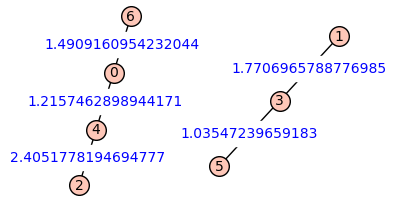

In [1]:
%run Packages_and_Functions.ipynb

import pandas as pd


In [4]:
algo_dict = {0 : 'DOMR',
            1 : 'PIVOT',
            2 : 'Pivot (Complete)',
            3: 'LHS',
            4: 'LHS (Complete)',
            5: 'L+1 Appx (general)',
            6: 'L+1 Appx (general, Complete)',
            7: 'L Appx (IOMR)',
            8: 'L Appx (IOMR, Complete)'}

In [5]:
### Experiment - Demonstrate Thereshold

def experiment_demonstrate_threshold(N = 30,AVG = 30, ps=20):
    delta = 1.9/ps
    P = [2 - i*delta for i in range(ps)]
    res = np.zeros((2,ps))
    for j,q in enumerate(P):
        print(f"finished {j/ps} percent")
        p = 1/np.power(N,q)
        tot = 0
        for trial in range(AVG):
            G = random_geometric_weighted_graph(N,p)
            while G.size() == 0: # Make sure the graph has edges
                G = random_geometric_weighted_graph(N,p)
            w = get_weights_vector(G,make_index_encoding(G))
            phi,count = induced_cycle_matrix(G)
            V = phi@w # potential deficit values for cycles
            tot +=np.count_nonzero(V < 0)
        res[0,j] = tot/AVG ### Broken Cycles
        res[1,j] = count # how many induced cycles 
    return res


### Experiment - Demonstrate Thereshold

def experiment_demonstrate_threshold_uniform(N = 30,AVG = 30, ps=20):
    delta = 1.9/ps
    P = [2 - i*delta for i in range(ps)]
    res = np.zeros((2,ps))
    for j,q in enumerate(P):
        print(f"finished {j*100/ps} percent")
        p = 1/np.power(N,q)
        tot = 0
        for trial in range(AVG):
            G = random_uniform_weighted_graph(N,p)
            while G.size() == 0: # Make sure the graph has edges
                G = random_uniform_weighted_graph(N,p)
            w = get_weights_vector(G,make_index_encoding(G))
            phi,count = induced_cycle_matrix(G)
            V = phi@w # potential deficit values for cycles
            tot +=np.count_nonzero(V < 0)
        res[0,j] = tot/AVG ### Broken induced Cycles
        res[1,j] = count # how many induced cycles 
    return res

def experiment_demonstrate_threshold_prob(N = 30,AVG = 30, ps=50,std=False):
    delta = 1.9/ps
    P = [2 - i*delta for i in range(ps)]
    res = np.zeros((2,ps))
    res_std = np.zeros((2,ps))
    for j,q in enumerate(P):
        print(f"finished {(j/ps)*100}%")
        p = 1/np.power(N,q)
        samples_broken=np.zeros(AVG)
        samples_cycles=np.zeros(AVG)
        has_broken = 0
        has_cycle = 0
        for trial in range(AVG):
            G = random_geometric_weighted_graph(N,p)
            while G.size() == 0: # Make sure the graph has edges
                G = random_geometric_weighted_graph(N,p)
            w = get_weights_vector(G,make_index_encoding(G))
            phi,count = induced_cycle_matrix(G)
            V = phi@w # potential deficit values for cycles
            if count > 0:
                samples_cycles[trial] = 1
                has_cycle +=1
            if np.count_nonzero(V < 0) > 0:
                samples_broken[trial] = 1
                has_broken +=1
        res[0,j] = has_broken/AVG ### Broken Cycles
        res[1,j] = has_cycle/AVG # how many induced cycles 
        res_std[0,j]=np.std(samples_broken)/np.sqrt(AVG)
        res_std[1,j]=np.std(samples_cycles)/np.sqrt(AVG)         
    if std:
        return res,res_std
    else:
        return res

In [1]:
### Experiment - how many edges we discard when running algorithms
def experiment_heuristics_on_G_and_KG(n1=50,n2=130,p = lambda x: np.power(x,-0.5),AVG = 30):
    """
    p would be a function of n, or a constant function. But we definitly expect it to be a function N -> (0,1)
    """
    N = range(n1,n2)
    res = np.zeros((9,len(N)))
    start_time = time.time()
    for i,n in enumerate(N):
        ### Keep track of progress
        if i % 5 == 0:
            print(f"Completed: {i/len(N)*100}% \n" + "Elapsed Time: " + str((time.time() - start_time)/60))
        ### Iterate over connected Components
        for j in range(AVG):
            B = False
            while B == False: # Make sure the graph is broken
                G = random_geometric_weighted_graph(n,p(n))
                DOMR_solns = list()
                for CC in connected_components_subgraphs(G):
                    DOMR = domr_alg(CC)
                    if len(DOMR) > 0:
                        B = True
                    DOMR_solns.append(len(DOMR))
                if B:
                    PIVOT_solns = list()
                    LHS_solns = list()
                    SPC_MR_solns = list()
                    SPC_IOMR_solns = list()
                    
                    COM_PIVOT_solns = list()
                    COM_LHS_solns = list()
                    COM_SPC_MR_solns = list()
                    COM_SPC_IOMR_solns = list()
                    
                    for CC in connected_components_subgraphs(G):
                        comCC = complete(CC)
                        PIVOT_solns.append(len(pivot_heuristic(CC)))
                        SPC_MR_solns.append(len(shortest_path_cover(CC)))
                        SPC_IOMR_solns.append(len(shortest_path_cover(CC,general=0)))
                        
                        LHS_solns.append(len(left_edge_heuristic(CC)))
                        COM_PIVOT_solns.append(len(pivot_heuristic(comCC)))
                        COM_LHS_solns.append(len(left_edge_heuristic(comCC)))
                        COM_SPC_MR_solns.append(len(shortest_path_cover(comCC)))
                        COM_SPC_IOMR_solns.append(len(shortest_path_cover(comCC,general=0)))
                    res[0,i] += sum(DOMR_solns)/AVG
                    res[1,i] += sum(PIVOT_solns)/AVG
                    res[2,i] += sum(COM_PIVOT_solns)/AVG
                    res[3,i] += sum(LHS_solns)/AVG
                    res[4,i] += sum(COM_LHS_solns)/AVG
                    res[5,i] += sum(SPC_MR_solns)/AVG
                    res[6,i] += sum(COM_SPC_MR_solns)/AVG
                    res[7,i] += sum(SPC_IOMR_solns)/AVG
                    res[8,i] += sum(COM_SPC_IOMR_solns)/AVG
    return res



In [1]:
def experiment_algs_as_function_of_p(start=1-0.01, end=0.1,ps=20,AVG = 30,n=100):
    delta = (start-end)/ps
    P = [end + delta*i for i in range(ps)]
    res = res = np.zeros((9,len(P)))
    start_time = time.time()

    for i,p in enumerate(P):
        if i % 5 == 0:
            print(f"Completed: {i/len(P)*100}% \n" + "Elapsed Time: " + str((time.time() - start_time)/60))
        for j in range(AVG):
            B = False
            while B == False: # Make sure the graph is broken
                G = random_geometric_weighted_graph(n,p)
                DOMR_solns = list()
                for CC in connected_components_subgraphs(G):
                    DOMR = domr_alg(CC)
                    if len(DOMR) > 0:
                        B = True
                    DOMR_solns.append(len(DOMR))
                if B:
                    PIVOT_solns = list()
                    LHS_solns = list()
                    SPC_MR_solns = list()
                    SPC_IOMR_solns = list()
                    
                    COM_PIVOT_solns = list()
                    COM_LHS_solns = list()
                    COM_SPC_MR_solns = list()
                    COM_SPC_IOMR_solns = list()
                    
                    for CC in connected_components_subgraphs(G):
                        comCC = complete(CC)
                        PIVOT_solns.append(len(pivot_heuristic(CC)))
                        SPC_MR_solns.append(len(shortest_path_cover(CC)))
                        SPC_IOMR_solns.append(len(shortest_path_cover(CC,general=0)))
                        
                        LHS_solns.append(len(left_edge_heuristic(CC)))
                        COM_PIVOT_solns.append(len(pivot_heuristic(comCC)))
                        COM_LHS_solns.append(len(left_edge_heuristic(comCC)))
                        COM_SPC_MR_solns.append(len(shortest_path_cover(comCC)))
                        COM_SPC_IOMR_solns.append(len(shortest_path_cover(comCC,general=0)))
                    res[0,i] += sum(DOMR_solns)/AVG
                    res[1,i] += sum(PIVOT_solns)/AVG
                    res[2,i] += sum(COM_PIVOT_solns)/AVG
                    res[3,i] += sum(LHS_solns)/AVG
                    res[4,i] += sum(COM_LHS_solns)/AVG
                    res[5,i] += sum(SPC_MR_solns)/AVG
                    res[6,i] += sum(COM_SPC_MR_solns)/AVG
                    res[7,i] += sum(SPC_IOMR_solns)/AVG
                    res[8,i] += sum(COM_SPC_IOMR_solns)/AVG
    return res


In [4]:
# print("####################\n")
# print("p=0.3")
# df = pd.DataFrame(experiment_heuristics_on_G_and_KG(p= lambda x: .3))
# df.to_csv("alg_p03.csv")


####################

p=0.3
Completed: 0.0% 
Elapsed Time: 4.4898192087809244e-05
Completed: 6.25% 
Elapsed Time: 6.768271565437317
Completed: 12.5% 
Elapsed Time: 16.423626232147218
Completed: 18.75% 
Elapsed Time: 29.649835097789765
Completed: 25.0% 
Elapsed Time: 47.277909048398335
Completed: 31.25% 
Elapsed Time: 70.03721588055292
Completed: 37.5% 
Elapsed Time: 106.79960371653239
Completed: 43.75% 
Elapsed Time: 144.8040504137675
Completed: 50.0% 
Elapsed Time: 191.9815643310547
Completed: 56.25% 
Elapsed Time: 306.56347409884137
Completed: 62.5% 
Elapsed Time: 383.04177063306173
Completed: 68.75% 
Elapsed Time: 485.7761433641116
Completed: 75.0% 
Elapsed Time: 611.4054822325706
Completed: 81.25% 
Elapsed Time: 732.1510858337084
Completed: 87.5% 
Elapsed Time: 872.655527484417
Completed: 93.75% 
Elapsed Time: 1031.4775888641675
